# Bloch ED: Haldane momentum-resolved many-body spectrum

This notebook runs projected Bloch-basis ED using `aidan_custom.bloch_ed` and plots the many-body spectrum resolved by crystal momentum sector.


In [1]:
import os

# Force CPU backend for this ED workflow (set before importing NetKet/JAX).
os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "")

import numpy as np
import matplotlib.pyplot as plt

from aidan_custom.bloch_ed import (
    build_haldane_projected_hamiltonian,
    solve_projected_all_momentum_sectors,
)


In [10]:
# Model and ED parameters
Lx = 4
Ly = 3
n_particles = 4
selected_bands = [0,1]

t1 = 1.0
t2 = -1.0 / (4.0 * np.cos(0.65))
phi = 0.65
m = 0.0
V1 = 10.0

# Diagonalization policy handled in source code:
# - dense if dim <= sparse_threshold
# - sparse if dim > sparse_threshold (using n_eigs_sparse if set)

sparse_threshold = 100
n_eigs_dense = 8
n_eigs_sparse = 20


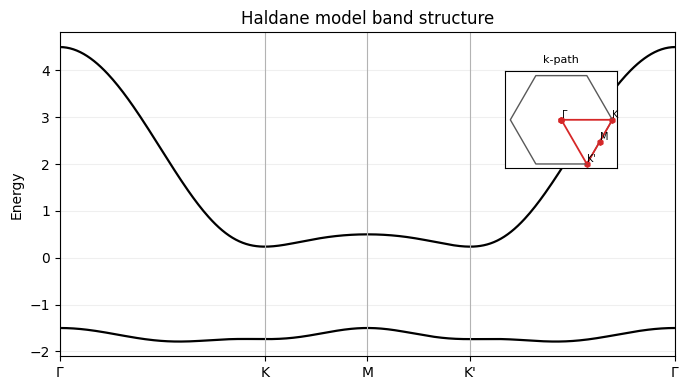

Estimated Chern number (lower band) = 1.0000000000
Estimated quantum weight (lower band) = 1.0664954341


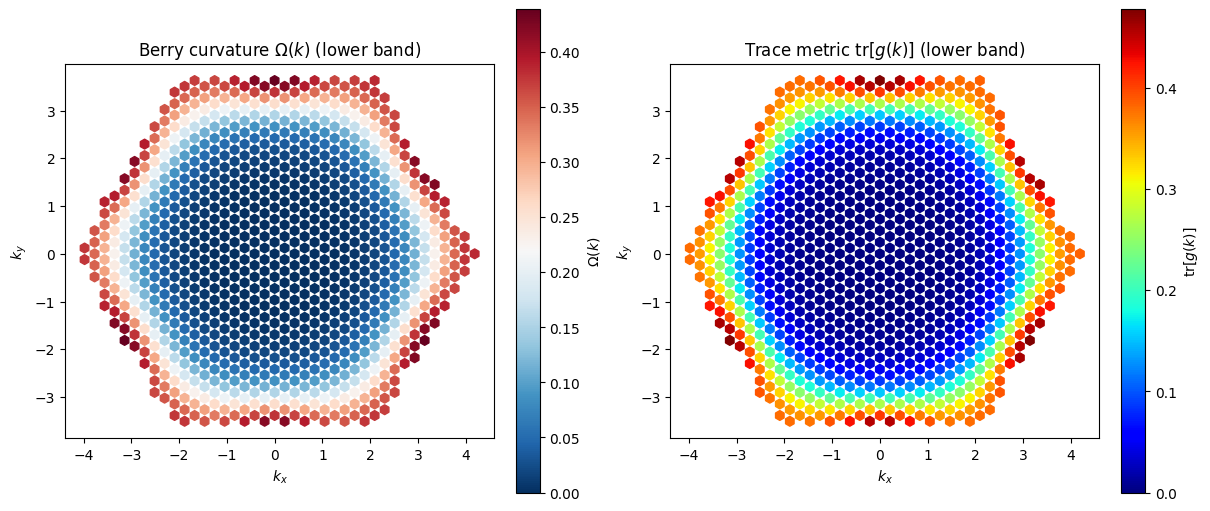

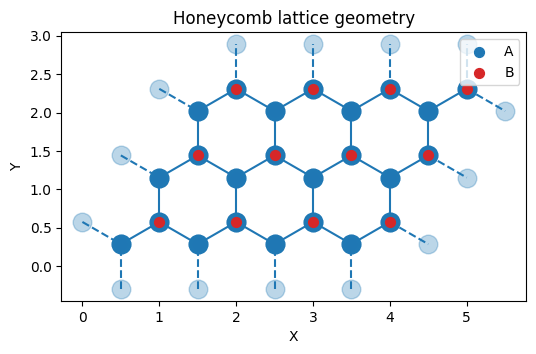

In [11]:
# Single-particle diagnostics: band structure + BZ geometry + Berry/QGT + lattice geometry
import netket as nk

from aidan_custom.geometry import (
    PRIMITIVE_A1,
    PRIMITIVE_A2,
    first_bz_hexagon_vertices,
    high_symmetry_points,
    k_path_gamma_k_m_kp_gamma,
    reciprocal_vectors,
    sample_shortest_representative_bz,
)
from aidan_custom.bandstructure import (
    berry_curvature_and_metric_trace_at_k,
    eigenvalues_at_k,
)

a1 = PRIMITIVE_A1.copy()
a2 = PRIMITIVE_A2.copy()
b1, b2 = reciprocal_vectors(a1, a2)

# 1) Band structure along high-symmetry path
k_points, x, x_nodes, labels = k_path_gamma_k_m_kp_gamma(120, b1, b2)
bands = np.array([eigenvalues_at_k(kx, ky, t1=t1, t2=t2, phi=phi, m=m) for kx, ky in k_points])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, bands[:, 0], color="black", lw=1.6)
ax.plot(x, bands[:, 1], color="black", lw=1.6)
for xn in x_nodes:
    ax.axvline(xn, color="0.7", lw=0.8)
ax.set_xticks(x_nodes)
ax.set_xticklabels(labels)
ax.set_xlim(x[0], x[-1])
ax.set_ylabel("Energy")
ax.set_title("Haldane model band structure")
ax.grid(axis="y", alpha=0.2)

gamma, k_node, m_node, kp_node = high_symmetry_points(b1, b2)
path_nodes = np.array([gamma, k_node, m_node, kp_node, gamma])
bz_hex = first_bz_hexagon_vertices(b1, b2)
bz_hex_closed = np.vstack([bz_hex, bz_hex[0]])

ax_in = ax.inset_axes([0.69, 0.58, 0.25, 0.30])
ax_in.plot(bz_hex_closed[:, 0], bz_hex_closed[:, 1], color="0.35", lw=1.0)
ax_in.plot(path_nodes[:, 0], path_nodes[:, 1], color="tab:red", lw=1.3)
ax_in.scatter(path_nodes[:, 0], path_nodes[:, 1], s=16, c="tab:red", marker="h")
for point, label in zip(path_nodes[:-1], labels[:-1]):
    ax_in.text(point[0], point[1], label, fontsize=7, ha="left", va="bottom")
ax_in.set_xticks([])
ax_in.set_yticks([])
ax_in.set_aspect("equal", "box")
ax_in.set_title("k-path", fontsize=8)
plt.tight_layout()
plt.show()

# 2) Report the same Berry/QGT quantities as in haldane_model.ipynb
_, kK, _, _ = high_symmetry_points(b1, b2)
omega_K, tr_g_K = berry_curvature_and_metric_trace_at_k(
    kK[0], kK[1], t1=t1, t2=t2, phi=phi, m=m, band="lower"
)

Lx_bz_plot = 30
Ly_bz_plot = Lx_bz_plot

k_bz_all = sample_shortest_representative_bz(Lx_bz_plot, Ly_bz_plot, b1, b2, unique=False)
if k_bz_all.size == 0:
    raise ValueError("No BZ points sampled. Increase Lx_bz_plot/Ly_bz_plot.")

berry_all = np.empty(k_bz_all.shape[0], dtype=float)
trg_all = np.empty(k_bz_all.shape[0], dtype=float)
for i, (kx, ky) in enumerate(k_bz_all):
    omega, trg = berry_curvature_and_metric_trace_at_k(
        kx, ky, t1=t1, t2=t2, phi=phi, m=m, band="lower"
    )
    berry_all[i] = omega
    trg_all[i] = trg

area_bz = abs(b1[0] * b2[1] - b1[1] * b2[0])
n_k = Lx_bz_plot * Ly_bz_plot
dk_area = area_bz / n_k
chern_number = (dk_area / (2.0 * np.pi)) * np.sum(berry_all)
quantum_weight = dk_area * np.sum(trg_all) / (2 * np.pi)
print(f"Estimated Chern number (lower band) = {chern_number:.10f}")
print(f"Estimated quantum weight (lower band) = {quantum_weight:.10f}")

# 3) Berry curvature and trace metric plots over the first BZ
k_bz = sample_shortest_representative_bz(Lx_bz_plot, Ly_bz_plot, b1, b2, unique=True)
berry_bz = np.empty(k_bz.shape[0], dtype=float)
trg_bz = np.empty(k_bz.shape[0], dtype=float)
for i, (kx, ky) in enumerate(k_bz):
    omega, trg = berry_curvature_and_metric_trace_at_k(
        kx, ky, t1=t1, t2=t2, phi=phi, m=m, band="lower"
    )
    berry_bz[i] = omega
    trg_bz[i] = trg

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
marker_size = 50
sc0 = axes[0].scatter(
    k_bz[:, 0],
    k_bz[:, 1],
    s=marker_size,
    c=berry_bz,
    cmap="RdBu_r",
    marker="h",
)
axes[0].set_title(r"Berry curvature $\Omega(k)$ (lower band)")
axes[0].set_xlabel(r"$k_x$")
axes[0].set_ylabel(r"$k_y$")
axes[0].set_aspect("equal", "box")
fig.colorbar(sc0, ax=axes[0], label=r"$\Omega(k)$")

sc1 = axes[1].scatter(
    k_bz[:, 0],
    k_bz[:, 1],
    s=marker_size,
    c=trg_bz,
    cmap="jet",
    marker="h",
)
axes[1].set_title(r"Trace metric $\mathrm{tr}[g(k)]$ (lower band)")
axes[1].set_xlabel(r"$k_x$")
axes[1].set_ylabel(r"$k_y$")
axes[1].set_aspect("equal", "box")
fig.colorbar(sc1, ax=axes[1], label=r"$\mathrm{tr}[g(k)]$")
plt.show()

# 4) Real-space lattice geometry
graph = nk.graph.Honeycomb(extent=[Lx, Ly], pbc=True)
ax = graph.draw(
    distance_order=1,
    draw_text=False,
    draw_basis_vectors=False,
    draw_unit_cell=False,
    node_size=180,
    figsize=(6, 6),
    show=False,
)
coords = graph.basis_coords
positions = graph.positions
a_sites = coords[:, 2] == 0
b_sites = coords[:, 2] == 1
ax.scatter(positions[a_sites, 0], positions[a_sites, 1], s=50, c="tab:blue", label="A", zorder=5)
ax.scatter(positions[b_sites, 0], positions[b_sites, 1], s=50, c="tab:red", label="B", zorder=5)
ax.set_title("Honeycomb lattice geometry")
ax.legend(loc="upper right")
plt.show()


In [12]:
projected_hamiltonian = build_haldane_projected_hamiltonian(
    Lx=Lx,
    Ly=Ly,
    t1=t1,
    t2=t2,
    phi=phi,
    m=m,
    selected_bands=selected_bands,
    V1=V1,
)

single_particle_energies = np.sort(np.real(np.linalg.eigvalsh(projected_hamiltonian.one_body)))
n_fermions_eff = int(n_particles)
if n_fermions_eff > single_particle_energies.size:
    raise ValueError(
        f"n_particles={n_fermions_eff} exceeds available single-particle states {single_particle_energies.size}."
    )
print("Single-particle Bloch-state energies on finite cluster (ascending):")
print(np.array2string(single_particle_energies, precision=10, separator=", "))
print(
    f"Sum of lowest {n_fermions_eff} single-particle energies = {single_particle_energies[:n_fermions_eff].sum():.10f}"
)

sector_results = solve_projected_all_momentum_sectors(
    projected_hamiltonian=projected_hamiltonian,
    n_particles=n_particles,
    n_eigs=n_eigs_dense,
    sparse_threshold=sparse_threshold,
    n_eigs_sparse=n_eigs_sparse,
    use_sparse=True,
)

sorted_sectors = sorted(sector_results.keys())
print(f"Number of non-empty momentum sectors: {len(sorted_sectors)}")
for sector in sorted_sectors:
    dim = len(sector_results[sector]["basis"].states)
    eigvals = np.asarray(sector_results[sector]["eigenvalues"], dtype=float)
    solver = sector_results[sector].get("solver", "unknown")
    print(
        f"sector={sector}, dim={dim}, solver={solver}, eigvals_computed={eigvals.size}, E0={eigvals[0]: .10f}"
    )


Single-particle Bloch-state energies on finite cluster (ascending):
[-1.7638103062, -1.7638103062, -1.7360679775, -1.7360679775, -1.7320508076,
 -1.7320508076, -1.7206765529, -1.7206765529, -1.6972606426, -1.6972606426,
 -1.5         , -1.5         ,  0.3546511491,  0.3546511491,  0.5         ,
  0.6972606426,  0.6972606426,  1.7320508076,  1.7320508076,  2.12983571  ,
  2.12983571  ,  2.7360679775,  2.7360679775,  4.5         ]
Sum of lowest 4 single-particle energies = -6.9997565675
Number of non-empty momentum sectors: 12
sector=(0, 0), dim=890, solver=sparse, eigvals_computed=20, E0=-6.6481942238
sector=(0, 1), dim=890, solver=sparse, eigvals_computed=20, E0=-6.5795869553
sector=(0, 2), dim=890, solver=sparse, eigvals_computed=20, E0=-6.5795869553
sector=(1, 0), dim=880, solver=sparse, eigvals_computed=20, E0=-6.5844569568
sector=(1, 1), dim=880, solver=sparse, eigvals_computed=20, E0=-6.6230005846
sector=(1, 2), dim=880, solver=sparse, eigvals_computed=20, E0=-6.6294405306
sector=

In [6]:
V1=1, 1 band: E0=-5.1486790397

2 band: -5.1581151039

SyntaxError: invalid syntax (3934035852.py, line 1)

In [ ]:
V1=10, 1 band: E0=-5.0669619611

2 band: E0=-5.0792370477

In [13]:
# Build arrays for plotting
plot_sectors = []
plot_x = []
plot_e = []
e0_grid = np.full((Lx, Ly), np.nan, dtype=float)

for idx, sector in enumerate(sorted_sectors):
    eigvals = np.asarray(sector_results[sector]["eigenvalues"], dtype=float)
    if eigvals.size == 0:
        continue
    e0_grid[sector[0], sector[1]] = eigvals[0]
    plot_sectors.append(sector)
    plot_x.extend([idx] * eigvals.size)
    plot_e.extend(eigvals.tolist())

plot_x = np.asarray(plot_x, dtype=float)
plot_e = np.asarray(plot_e, dtype=float)


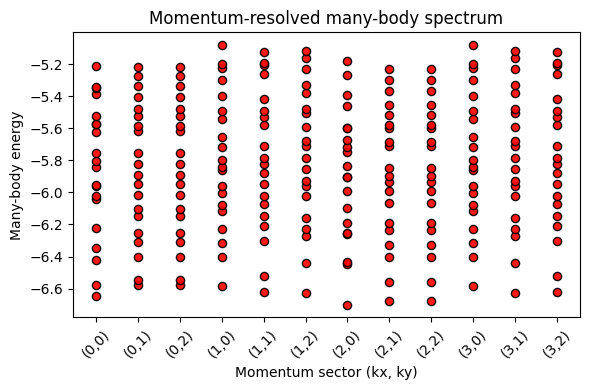

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(plot_x, plot_e, s=35, alpha=0.9,color="red",edgecolors="black")
ax.set_xticks(np.arange(len(plot_sectors)))
ax.set_xticklabels([f"({kx},{ky})" for (kx, ky) in plot_sectors], rotation=45)
ax.set_xlabel("Momentum sector (kx, ky)")
ax.set_ylabel("Many-body energy")
ax.set_title("Momentum-resolved many-body spectrum")
# ax.grid(alpha=0.25)
# plt.ylim(-5.6,-2)
plt.tight_layout()
plt.show()
